# strattest research

## Testing a trading strategy I found on YouTube

There is no shortage of trading strategies online. YouTube, Reddit, X and trading communities are full of traders sharing systems they say are profitable, usually backed by a handful of examples on a chart.

strattest takes those strategies and tests them properly. We translate the idea into clear rules, run it against years of historical market data, and report what actually happened.

For this first study, we went to YouTube and searched for **"profitable forex strategy."** One of the top results presented a simple scalping strategy the creator describes as rule-based and profitable across forex, gold and crypto. That is the strategy we test in this notebook.

**Source:** [YouTube video](https://www.youtube.com/watch?v=O5eC5lY7ZXY)

We are not setting out to prove the strategy right or wrong. The aim is to understand it, test it as closely as possible to how its creator presents it, and let the data show how it behaves.

# The strategy

The creator presents this as a scalping strategy built on a single reference candle: the first 4-hour candle of the day. He demonstrates it on Bitcoin, EURUSD and gold.

## The rules, as presented

**Step 1: Mark the range**
- Set the chart to New York time.
- Find the first 4-hour candle that forms on the current date.
- Wait for that candle to fully close, then mark its high and low. This is the 4-hour range.

**Step 2: Find the setup on the 5-minute chart**
- Wait for a 5-minute candle to close outside the range. A wick outside the range does not count.
- Then wait for a 5-minute candle to close back inside the range.
- All of this must happen on the same day as the range.

**Step 3: Enter the trade**
- A break above the range followed by a close back inside is a short.
- A break below the range followed by a close back inside is a long.
- The stop goes at the high or low of the breakout move.
- The target is two times the stop size (2R).

More than one trade can be taken in a day, as long as a new valid setup appears before the day ends.

## Where the video is unclear, and how we handle it

Some parts of the strategy are not fully defined in the video. Here is how we treat each one in this research.

- **Large breakouts.** When price breaks out and travels far beyond the range before coming back in, the creator does not place the stop at the breakout extreme. He places it at the nearest swing point closer to the range. We adopt this approach. Since the video does not define what counts as "too large," we set a fixed definition of a large breakout, and of the swing point used for the stop, before running the test.
- **Which 4-hour candle.** We use New York time and take the first 4-hour candle of the day.
- **End of day.** The video does not say what happens to a trade still open when the day ends. We close any open trade at the end of the day.
- **Overlapping trades.** The video does not say whether a new setup can be taken while a trade is still open. We allow one trade at a time. A new setup is only taken once the previous trade has closed.

# What we want to find out

The goal is to understand how this strategy behaves when it is applied consistently over several years of data, not just a handful of hand-picked days.

**How often it trades**
- How often does a valid setup appear?
- How many trades does the strategy take per day, per month and per year?

**How trades turn out**
- How often do trades reach the target, hit the stop, or get closed at the end of the day?
- What is the win rate, and what does the strategy return in R over the full period?
- What do losing streaks and drawdowns look like?

**Large breakouts**
- How often does a breakout count as large, and how do those trades perform compared to the rest?

**Markets and time**
- Does the strategy behave differently on EURUSD, gold and Bitcoin?
- Are the results consistent from year to year, or concentrated in particular periods?

**Trading costs**
- Do the results still hold once spread is taken into account?

**A second reference candle**
- Separately, we repeat the test using the first 4-hour candle of the London morning, to see whether the choice of reference candle changes the results.

# 1. Data preparation

In this section we prepare the market data used throughout the research.

We fetch 5-minute candles for EURUSD, gold and Bitcoin from MetaTrader 5, covering the same period for each market. The 4-hour reference candle is built later from this 5-minute data in New York time, so no separate 4-hour data is needed.

Before using the data, we run a short quality check on each market: the number of candles, the period covered, duplicate timestamps, and days with missing data. The aim is to confirm the data is usable and to note any problems, not to repair or fill in missing candles.

MetaTrader 5 timestamps are in the broker's server time, so we convert them to New York time before saving the prepared data to `data/raw`.

In [1]:
# we import the liraries we will need
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
# config
symbols = ["EURUSD", "XAUUSD", "BTCUSD"]

start_date = datetime(2020, 1, 1)
end_date = datetime(2026, 1, 1)

timeframe = mt5.TIMEFRAME_M5

# broker clock runs this many hours ahead of New York (verified in the next cell)
broker_ny_offset_hours = 7

# connect to MetaTrader 5 terminal
if not mt5.initialize():
    raise RuntimeError("Failed to initialize MetaTrader 5")

data = {} # an emty dictionary to hold the datasets

for symbol in symbols:
    # make sure the symbol is available in Market Watch
    mt5.symbol_select(symbol, True)

    rates = mt5.copy_rates_range(symbol, timeframe, start_date, end_date)

    # stop here rather than carry an empty dataset forward
    if rates is None or len(rates) == 0:
        mt5.shutdown()
        raise RuntimeError(f"No data returned for {symbol}: {mt5.last_error()}")

    df = pd.DataFrame(rates)

    # keep prices and spread (spread is needed later for trading costs)
    df = df[["time", "open", "high", "low", "close", "spread"]]

    # broker timestamps, exactly as delivered
    df["time"] = pd.to_datetime(df["time"], unit="s")

    # same candles, labelled on the New York clock
    df["ny_time"] = df["time"] - pd.Timedelta(hours=broker_ny_offset_hours)

    data[symbol] = df

# close MetaTrader 5 connection
mt5.shutdown()

for symbol, df in data.items():
    print(f"{symbol}: {len(df)} candles")

EURUSD: 448033 candles
XAUUSD: 425590 candles
BTCUSD: 588031 candles


Before trusting the New York time column, we verify the 7-hour offset. Forex and gold open once a week after the weekend break. If the broker's clock is always 7 hours ahead of New York, each weekly open should land at the same New York time all year, in winter and summer alike.

In [3]:
# config
clock_check_symbols = ["EURUSD", "XAUUSD"]

for symbol in clock_check_symbols:
    df = data[symbol]

    # a new week starts after a gap of more than one day (the weekend)
    week_start = df["time"].diff() > pd.Timedelta(days=1)
    week_opens = df.loc[week_start, ["time", "ny_time"]].copy()

    # weekday and time of each weekly open, on the New York clock
    week_opens["ny_open"] = week_opens["ny_time"].dt.strftime("%a %H:%M")

    print(f"\n{symbol}: {len(week_opens)} week opens")
    print(week_opens["ny_open"].value_counts())


EURUSD: 316 week opens
ny_open
Sun 17:00    304
Sun 17:05      3
Mon 17:00      3
Sun 18:00      2
Wed 17:00      2
Sun 17:15      1
Thu 17:00      1
Name: count, dtype: int64

XAUUSD: 316 week opens
ny_open
Sun 18:00    308
Mon 18:00      4
Wed 18:00      2
Sun 18:15      1
Thu 18:00      1
Name: count, dtype: int64


A quick summary of each dataset: how many candles it holds, 
the period it covers, and whether the timestamps are unique and in order.

In [4]:
summary = {}

for symbol, df in data.items():
    summary[symbol] = {
        "Candles": len(df),
        "First candle (NY)": df["ny_time"].min(),
        "Last candle (NY)": df["ny_time"].max(),
        "Days with data": df["ny_time"].dt.date.nunique(),
        "Duplicate timestamps": df["time"].duplicated().sum(),
        "In time order": df["time"].is_monotonic_increasing
    }

pd.DataFrame(summary)

,EURUSD,XAUUSD,BTCUSD
Candles,448033,425590,588031
First candle (NY),2020-01-01 17:00:00,2020-01-01 18:00:00,2020-01-01 17:05:00
Last candle (NY),2025-12-31 16:00:00,2025-12-31 16:00:00,2025-12-31 16:00:00
Days with data,1874,1866,2136
Duplicate timestamps,0,0,0
In time order,True,True,True


Next we check for missing data. A New York calendar day does not always hold the same number of candles: forex opens on Sunday evening and closes on Friday afternoon. So instead of flagging every day below a fixed count, we look at the typical number of candles on each weekday, and then check the part the strategy depends on: whether the reference window, 01:00 to 05:00 New York, has all 48 of its 5-minute candles.

In [5]:
# config
# reference window on the New York clock: 01:00 up to 05:00
window_start_hour = 1
window_end_hour = 5

# 4 hours of 5-minute candles
window_candles = 48

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_checks = {}

for symbol, df in data.items():
    # New York date and weekday, kept on the dataset for the rest of the research
    df["ny_date"] = df["ny_time"].dt.date
    df["ny_weekday"] = df["ny_time"].dt.day_name()

    # candles per New York day
    daily = df.groupby("ny_date").agg(
        weekday=("ny_weekday", "first"),
        candles=("time", "size")
    )

    # candles inside the reference window each day
    hour = df["ny_time"].dt.hour
    in_window = (hour >= window_start_hour) & (hour < window_end_hour)

    daily["window_candles"] = df[in_window].groupby("ny_date").size()
    daily["window_candles"] = daily["window_candles"].fillna(0).astype(int)
    daily["window_complete"] = daily["window_candles"] == window_candles

    # kept so incomplete reference windows can be excluded later
    daily_checks[symbol] = daily

    # one row per weekday
    by_weekday = daily.groupby("weekday").agg(
        days=("candles", "size"),
        median_candles=("candles", "median"),
        min_candles=("candles", "min"),
        window_complete=("window_complete", "sum")
    ).reindex(weekday_order).dropna()

    by_weekday["window_incomplete"] = by_weekday["days"] - by_weekday["window_complete"]

    print(f"\n{symbol}")
    display(by_weekday)


EURUSD


,days,median_candles,min_candles,window_complete,window_incomplete
weekday,,,,,
Monday,313.0,288.0,84.0,309.0,4.0
Tuesday,313.0,288.0,204.0,312.0,1.0
Wednesday,314.0,288.0,84.0,311.0,3.0
Thursday,313.0,288.0,84.0,311.0,2.0
Friday,311.0,204.0,168.0,311.0,0.0
Sunday,310.0,84.0,72.0,0.0,310.0



XAUUSD


,days,median_candles,min_candles,window_complete,window_incomplete
weekday,,,,,
Monday,313.0,276.0,72.0,308.0,5.0
Tuesday,313.0,276.0,165.0,312.0,1.0
Wednesday,314.0,276.0,72.0,311.0,3.0
Thursday,313.0,276.0,72.0,311.0,2.0
Friday,304.0,204.0,156.0,303.0,1.0
Sunday,309.0,72.0,69.0,0.0,309.0



BTCUSD


,days,median_candles,min_candles,window_complete,window_incomplete
weekday,,,,,
Monday,313,287.0,281,311,2
Tuesday,313,287.0,285,313,0
Wednesday,314,287.0,83,313,1
Thursday,313,287.0,168,313,0
Friday,311,276.0,200,311,0
Saturday,259,287.0,144,254,5
Sunday,313,287.0,82,252,61


The broker did not provide weekend Bitcoin data for part of the test period. 
To keep every year comparable, we exclude weekends from the Bitcoin test entirely.
there a few days missing in the other datasets except for weekends, but that is not 
really enough to effect our backtest.  so we'll save the data and proceed  

In [7]:
# save prepared 5M datasets
for symbol, df in data.items():
    weekdays_only = df[~df["ny_weekday"].isin(["Saturday", "Sunday"])]
    weekdays_only.to_csv(f"../data/raw/{symbol}_5M.csv")

# 2. Strategy rules and features

This section sets out the exact rules used to test the strategy, then builds the information the trade simulation needs. Every rule below is fixed before any results are seen.

## The trading day (New York time)

- **Reference candle:** 00:00 to 04:00. Its high and low form the range. A day is only used if all 48 five-minute candles in this window are present.
- **Setup window:** from 04:00 until midnight.
- **End of day:** any open trade is closed at the last candle before midnight. On Fridays, every market stops at 17:00.
- Weekends are excluded for all markets.

## Setups

- **Breakout:** a 5-minute candle closes above the range high or below the range low. Wicks alone do not count.
- **Re-entry:** after a breakout, a 5-minute candle closes back inside the range.
- A break above followed by a re-entry is a **short**. A break below followed by a re-entry is a **long**.
- If price closes above the range and then closes below it without closing inside, the first breakout ends and a new breakout below begins.

## Entry

- The trade opens at the **open of the candle after the re-entry candle**.
- If the re-entry happens on the last candle before the end of the day, there is no trade.
- Only one trade is open at a time. After a trade closes, a new setup needs a fresh breakout that starts after the exit.

## Stop

- **Normal breakout:** the stop goes at the highest high (for a short) or lowest low (for a long) from the breakout candle to the re-entry candle.
- **Large breakout:** a breakout is large when the distance from entry to that extreme is more than **2 times the range height**. The stop then goes at the swing point closest to the range, formed after the breakout extreme and confirmed before entry. A swing high is a candle whose high is above the 2 candles on either side; a swing low is the mirror of this.
- **Large breakout with no swing point:** no trade is taken. These setups are recorded separately.

## Target and exits

- The target is **2R** from the entry price.
- Stop and target checks start from the entry candle itself.
- If a single candle touches both the stop and the target, the trade is counted as a loss.
- If a candle opens beyond the stop, the trade exits at that candle's open.

## Trading costs

Results are reported before trading costs. The spread recorded by MetaTrader 5 for this account is mostly zero and does not reflect what a typical retail trader pays, so costs are left out.

We start with the settings for this run: which market to test, the reference window, the fixed rule parameters, and the period used while the rules are being built and checked. The prepared 5-minute data for the selected market is then loaded and cut to that period.

In [97]:
# config
symbol = "XAUUSD"

# reference window (New York time)
window = "NY"
window_start_hour = 0
window_end_hour = 4

# Friday cutoff for all markets (New York time)
friday_close_hour = 17

# rule parameters, fixed before testing
target_r = 2
large_breakout_multiple = 2
swing_candles = 2

# development slice (New York time)
slice_start = "2020-01-01"
slice_end = "2026-01-01"

# price value of one spread point for each market
point_size = {
    "EURUSD": 0.00001,
    "XAUUSD": 0.01,
    "BTCUSD": 0.01
}

# load prepared 5M data, with timestamps read as dates
df = pd.read_csv(f"../data/raw/{symbol}_5M.csv", parse_dates=["time", "ny_time"])

# drop the old saved index if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# CSV stores the New York date as text, so convert it back
df["ny_date"] = pd.to_datetime(df["ny_date"]).dt.date

# keep only the development slice
df = df[(df["ny_time"] >= slice_start) & (df["ny_time"] < slice_end)].reset_index(drop=True)

print(f"{symbol}: {len(df)} candles, {df['ny_time'].min()} to {df['ny_time'].max()}")

XAUUSD: 403350 candles, 2020-01-01 18:00:00 to 2025-12-31 16:00:00


Next we build the daily range table: one row per New York day, holding the high and low of the reference window. A day's range is only valid if every 5-minute candle in the window is present. Days without a complete window, such as holidays, stay in the table but are marked invalid, so they can be counted later.

In [98]:
# config
# number of 5 minute candles in a complete reference window
expected_window_candles = (window_end_hour - window_start_hour) * 12  

# every New York day in the slice, including days with no reference window
daily = df.groupby("ny_date").agg(weekday=("ny_weekday", "first"))

# candles inside the reference window, selected by timestamp
hour = df["ny_time"].dt.hour
in_window = (hour >= window_start_hour) & (hour < window_end_hour)

window_stats = df[in_window].groupby("ny_date").agg(
    range_high=("high", "max"),
    range_low=("low", "min"),
    range_candles=("time", "size")
)

# attach window stats to every day (days without a window get NaN)
daily = daily.join(window_stats)
daily["range_candles"] = daily["range_candles"].fillna(0).astype(int)

daily["range_height"] = daily["range_high"] - daily["range_low"]
daily["valid_range"] = daily["range_candles"] == expected_window_candles

print(f"days: {len(daily)}, valid ranges: {daily['valid_range'].sum()}")
daily.head(10)

days: 1557, valid ranges: 1543


,weekday,range_high,range_low,range_candles,range_height,valid_range
ny_date,,,,,,
2020-01-01,Wednesday,NaN,NaN,0,NaN,False
2020-01-02,Thursday,1521.45,1518.49,48,2.96,True
2020-01-03,Friday,1545.36,1538.29,48,7.07,True
2020-01-06,Monday,1577.84,1570.26,48,7.58,True
2020-01-07,Tuesday,1570.87,1559.04,48,11.83,True
2020-01-08,Wednesday,1595.35,1580.06,48,15.29,True
2020-01-09,Thursday,1559.02,1540.27,48,18.75,True
2020-01-10,Friday,1552.49,1546.25,48,6.24,True
2020-01-13,Monday,1556.46,1549.92,48,6.54,True


We now attach each day's range to its 5-minute candles and record where every candle closed: above the range, inside it, or below it. This is only recorded from 04:00 onward on days with a valid range, since that is when the strategy starts watching for setups.

In [99]:
# attach each day's range to its 5-minute candles
df = df.merge(
    daily[["range_high", "range_low", "valid_range"]],
    left_on="ny_date",
    right_index=True,
    how="left"
)

# setup window: from the end of the reference candle onward, on valid days only
in_setup_window = (df["ny_time"].dt.hour >= window_end_hour) & df["valid_range"]

# where each candle closed: 1 above the range, -1 below, 0 inside
df["position"] = np.where(
    df["close"] > df["range_high"], 1,
    np.where(df["close"] < df["range_low"], -1, 0)
)

# outside the setup window, position has no meaning
df.loc[~in_setup_window, "position"] = np.nan

df["position"].value_counts(dropna=False)

position
 0.0    126651
 1.0    107733
-1.0     92867
 NaN     76099
Name: count, dtype: int64

Next we mark swing points, which the strategy uses to place the stop on large breakouts. A swing high is a candle whose high is above the highs of the 2 candles before it and the 2 candles after it. A swing low is the mirror of this.

Because a swing point depends on the 2 candles after it, it is only known once those candles have closed. The flag below marks where a swing formed, and the trade simulation only uses a swing once it would have been visible to a trader.

In [100]:
# a swing high must be above the highs of the candles on each side; a swing low below their lows
swing_high = pd.Series(True, index=df.index)
swing_low = pd.Series(True, index=df.index)

for k in range(1, swing_candles + 1):
    swing_high &= (df["high"] > df["high"].shift(k)) & (df["high"] > df["high"].shift(-k))
    swing_low &= (df["low"] < df["low"].shift(k)) & (df["low"] < df["low"].shift(-k))

# flags mark where a swing formed; it is confirmed swing_candles candles later
df["swing_high"] = swing_high
df["swing_low"] = swing_low

print(f"swing highs: {df["swing_high"].sum()}, swing lows: {df["swing_low"].sum()}")

swing highs: 52752, swing lows: 53203


# 3. Trade simulation

In this section we walk through each valid day candle by candle, from 04:00 New York time until the day's cutoff, applying the rules exactly as written in Section 2. Every trade is recorded in a trade log, and every setup skipped under the large-breakout rule is recorded separately.

The first step is the stop rule. On a normal breakout, the stop sits at the breakout extreme. On a large breakout, it moves to the confirmed swing point closest to the range, and if there is no such swing, the setup is skipped.

In [101]:
# config
# setup window: valid days from 04:00, before the Friday cutoff
is_friday = df["ny_weekday"] == "Friday"
before_cutoff = ~is_friday | (df["ny_time"].dt.hour < friday_close_hour)

setup = df[df["position"].notna() & before_cutoff].reset_index(drop=True)

# numpy arrays for fast access inside the loop
times = setup["ny_time"].to_numpy()
opens = setup["open"].to_numpy()
highs = setup["high"].to_numpy()
lows = setup["low"].to_numpy()
closes = setup["close"].to_numpy()
positions = setup["position"].to_numpy()
swing_highs = setup["swing_high"].to_numpy()
swing_lows = setup["swing_low"].to_numpy()
spreads = setup["spread"].to_numpy()


def find_stop(direction, extreme, extreme_idx, reentry_idx, entry, range_high, range_low, range_height):
    """Return (stop, stop_type) for a setup, or (None, skip_reason) if no trade should be taken."""

    # normal breakout: stop at the breakout extreme
    if abs(extreme - entry) <= large_breakout_multiple * range_height:
        stop = extreme
        stop_type = "extreme"

    # large breakout: closest confirmed swing to the range
    else:
        # a swing is confirmed once swing_candles candles after it have closed,
        # and those must have closed by the re-entry candle
        last_usable = reentry_idx - swing_candles
        candidates = range(extreme_idx + 1, last_usable + 1)

        if direction == "short":
            levels = [highs[j] for j in candidates if swing_highs[j] and highs[j] > range_high]
        else:
            levels = [lows[j] for j in candidates if swing_lows[j] and lows[j] < range_low]

        if not levels:
            return None, "large_no_swing"

        # closest to the range: lowest swing high for a short, highest swing low for a long
        stop = min(levels) if direction == "short" else max(levels)
        stop_type = "swing"

    # the stop must sit on the losing side of the entry
    if (direction == "short" and stop <= entry) or (direction == "long" and stop >= entry):
        return None, "invalid_risk"

    return stop, stop_type

Next, the trade itself. From the entry candle onward, each candle is checked in order: a gap through the stop or target fills at the open, a candle touching both stop and target counts as a loss, and a trade still open at the day's cutoff closes at the last candle. Along the way we track the best and worst price reached, to measure how far each trade moved for and against us.

In [102]:
def simulate_trade(direction, entry_idx, last_idx, entry, stop, target, cutoff_reason):
    """Run a trade from the entry candle to its exit.

    Returns the exit index, exit price, exit reason, and the best and worst prices reached.
    """
    best = entry
    worst = entry

    for k in range(entry_idx, last_idx + 1):

        if direction == "short":
            # after the entry candle, an open beyond the stop or target fills at the open
            if k > entry_idx and opens[k] >= stop:
                return k, opens[k], "stop_gap", best, worst
            if k > entry_idx and opens[k] <= target:
                return k, opens[k], "target_gap", best, worst

            # for a short, favourable is down, adverse is up
            best = min(best, lows[k])
            worst = max(worst, highs[k])

            hit_stop = highs[k] >= stop
            hit_target = lows[k] <= target

        else:
            if k > entry_idx and opens[k] <= stop:
                return k, opens[k], "stop_gap", best, worst
            if k > entry_idx and opens[k] >= target:
                return k, opens[k], "target_gap", best, worst

            # for a long, favourable is up, adverse is down
            best = max(best, highs[k])
            worst = min(worst, lows[k])

            hit_stop = lows[k] <= stop
            hit_target = highs[k] >= target

        # both touched in one candle: order unknown, counted as a loss
        if hit_stop and hit_target:
            return k, stop, "both_touched", best, worst
        if hit_stop:
            return k, stop, "stop", best, worst
        if hit_target:
            return k, target, "target", best, worst

        # still open on the last candle before the cutoff: close at its close
        if k == last_idx:
            return k, closes[k], cutoff_reason, best, worst

Finally, the day loop. For each valid day, we walk through the candles from 04:00 in order. We watch for a breakout, track its extreme, and when price closes back inside the range we apply the stop rule and run the trade. Once a trade closes, we go back to watching for a fresh breakout. Each day's number of setups, trades and skipped setups is added to the daily table.

In [103]:
trades = []
skipped = []
day_counts = {}

for day, idx in setup.groupby("ny_date").indices.items():
    first = idx[0]
    last = idx[-1]

    weekday = setup.at[first, "ny_weekday"]
    cutoff_reason = "friday_close" if weekday == "Friday" else "end_of_day"

    range_high = setup.at[first, "range_high"]
    range_low = setup.at[first, "range_low"]
    range_height = range_high - range_low

    setups_found = 0
    trade_number = 0
    skipped_count = 0

    state = "watching"
    i = first

    while i <= last:
        pos = positions[i]

        # watching: any close outside the range starts a breakout
        if state == "watching":
            if pos != 0:
                state = "breakout"
                breakout_dir = pos
                breakout_idx = i
                extreme = highs[i] if pos == 1 else lows[i]
                extreme_idx = i
            i += 1
            continue

        # in breakout, still outside on the same side: keep tracking the extreme
        if pos == breakout_dir:
            if pos == 1 and highs[i] > extreme:
                extreme, extreme_idx = highs[i], i
            if pos == -1 and lows[i] < extreme:
                extreme, extreme_idx = lows[i], i
            i += 1
            continue

        # closed through to the other side: the old breakout ends, a new one starts here
        if pos == -breakout_dir:
            breakout_dir = pos
            breakout_idx = i
            extreme = highs[i] if pos == 1 else lows[i]
            extreme_idx = i
            i += 1
            continue

        # re-entry: the re-entry candle is still part of the breakout move
        if breakout_dir == 1 and highs[i] > extreme:
            extreme, extreme_idx = highs[i], i
        if breakout_dir == -1 and lows[i] < extreme:
            extreme, extreme_idx = lows[i], i

        setups_found += 1
        state = "watching"
        reentry_idx = i
        direction = "short" if breakout_dir == 1 else "long"
        entry_idx = i + 1

        # no candle left to enter on before the cutoff: no trade
        if entry_idx > last:
            i += 1
            continue

        entry = opens[entry_idx]

        stop, stop_info = find_stop(
            direction, extreme, extreme_idx, reentry_idx, entry,
            range_high, range_low, range_height
        )

        # no valid stop: record the skipped setup and keep watching
        if stop is None:
            skipped_count += 1
            skipped.append({
                "symbol": symbol,
                "window": window,
                "ny_date": day,
                "direction": direction,
                "breakout_time": times[breakout_idx],
                "reentry_time": times[reentry_idx],
                "breakout_extreme": extreme,
                "entry_price": entry,
                "stop_distance": abs(extreme - entry),
                "range_height": range_height,
                "skip_reason": stop_info
            })
            i += 1
            continue

        risk = abs(entry - stop)
        target = entry - target_r * risk if direction == "short" else entry + target_r * risk

        exit_idx, exit_price, exit_reason, best, worst = simulate_trade(
            direction, entry_idx, last, entry, stop, target, cutoff_reason
        )

        # results in R: positive is profit, measured against the risk taken
        if direction == "short":
            result_r = (entry - exit_price) / risk
            mfe_r = (entry - best) / risk
            mae_r = (worst - entry) / risk
        else:
            result_r = (exit_price - entry) / risk
            mfe_r = (best - entry) / risk
            mae_r = (entry - worst) / risk

        # spread of the entry candle, converted from points to price, then to R
        spread_cost_r = spreads[entry_idx] * point_size[symbol] / risk

        trade_number += 1
        trades.append({
            "symbol": symbol,
            "window": window,
            "ny_date": day,
            "weekday": weekday,
            "trade_number": trade_number,
            "range_high": range_high,
            "range_low": range_low,
            "range_height": range_height,
            "direction": direction,
            "breakout_time": times[breakout_idx],
            "breakout_extreme": extreme,
            "reentry_time": times[reentry_idx],
            "entry_time": times[entry_idx],
            "entry_price": entry,
            "stop": stop,
            "target": target,
            "risk": risk,
            "large_breakout": abs(extreme - entry) > large_breakout_multiple * range_height,
            "stop_type": stop_info,
            "exit_time": times[exit_idx],
            "exit_price": exit_price,
            "exit_reason": exit_reason,
            "bars_held": exit_idx - entry_idx + 1,
            "result_r": result_r,
            "spread_points": spreads[entry_idx],
            "spread_cost_r": spread_cost_r,
            "result_r_net": result_r - spread_cost_r,
            "mfe_r": mfe_r,
            "mae_r": mae_r
        })

        # resume on the candle after the exit
        i = exit_idx + 1

        # if the exit candle closed outside the range, a breakout is already under way.
        # it started at the first close outside in this run, possibly while the trade was open
        if positions[exit_idx] != 0:
            run_start = exit_idx
            while run_start - 1 >= first and positions[run_start - 1] == positions[exit_idx]:
                run_start -= 1

            state = "breakout"
            breakout_dir = positions[exit_idx]
            breakout_idx = run_start

            # extreme of the whole excursion so far
            if breakout_dir == 1:
                extreme_idx = run_start + int(np.argmax(highs[run_start:exit_idx + 1]))
                extreme = highs[extreme_idx]
            else:
                extreme_idx = run_start + int(np.argmin(lows[run_start:exit_idx + 1]))
                extreme = lows[extreme_idx]

    day_counts[day] = (setups_found, trade_number, skipped_count)

trades = pd.DataFrame(trades)
skipped = pd.DataFrame(skipped)

# add each day's counts to the daily table (invalid days get zeros)
counts = pd.DataFrame.from_dict(day_counts, orient="index", columns=["setups", "trades", "skipped"])
daily = daily.drop(columns=["setups", "trades", "skipped"], errors="ignore").join(counts)
daily[["setups", "trades", "skipped"]] = daily[["setups", "trades", "skipped"]].fillna(0).astype(int)

print(f"trades: {len(trades)}, skipped: {len(skipped)}")
trades["exit_reason"].value_counts()

trades: 3139, skipped: 44


exit_reason
stop            1705
target           803
end_of_day       490
friday_close     114
both_touched      20
stop_gap           5
target_gap         2
Name: count, dtype: int64

To check the trades by eye, we plot any trade from the trade log on the 5-minute chart. Each chart starts at the beginning of the trade's New York day, so the reference range is visible, and runs a few candles past the exit. It shows the range, the breakout and re-entry candles, and the entry, stop, target and exit.

In [104]:
import mplfinance as mpf


def get_trade_data(trade_num, candles_after=30):
    # get the trade
    trade = trades.iloc[trade_num]

    entry_time = pd.Timestamp(trade["entry_time"])
    exit_time = pd.Timestamp(trade["exit_time"])
    breakout_time = pd.Timestamp(trade["breakout_time"])
    reentry_time = pd.Timestamp(trade["reentry_time"])

    # chart starts at the beginning of the trade's New York day, so the range is visible
    day_start = pd.Timestamp(trade["ny_date"])
    chart = df[df["ny_time"] >= day_start].set_index("ny_time")

    # and ends a few candles after the exit
    exit_pos = chart.index.get_loc(exit_time)
    chart = chart.iloc[:exit_pos + candles_after + 1][["open", "high", "low", "close"]]

    return {
        "trade": trade,
        "chart": chart,
        "day_start": day_start,
        "entry_time": entry_time,
        "exit_time": exit_time,
        "breakout_time": breakout_time,
        "reentry_time": reentry_time
    }


def plot_trade_5m(trade_num, candles_after=30):
    d = get_trade_data(trade_num, candles_after)
    trade = d["trade"]
    chart = d["chart"]

    # price decimals for the title: 5 for forex, 2 otherwise
    decimals = 5 if point_size[symbol] < 0.001 else 2

    # markers: breakout and re-entry at their closes, entry and exit at their prices
    breakout_marker = pd.Series(np.nan, index=chart.index)
    breakout_marker[d["breakout_time"]] = chart.loc[d["breakout_time"], "close"]

    reentry_marker = pd.Series(np.nan, index=chart.index)
    reentry_marker[d["reentry_time"]] = chart.loc[d["reentry_time"], "close"]

    entry_marker = pd.Series(np.nan, index=chart.index)
    entry_marker[d["entry_time"]] = trade["entry_price"]

    exit_marker = pd.Series(np.nan, index=chart.index)
    exit_marker[d["exit_time"]] = trade["exit_price"]

    addplots = [
        mpf.make_addplot(breakout_marker, type="scatter", marker="o", markersize=80, color="orange"),
        mpf.make_addplot(reentry_marker, type="scatter", marker="o", markersize=80, color="purple"),
        mpf.make_addplot(
            entry_marker,
            type="scatter",
            marker="^" if trade["direction"] == "long" else "v",
            markersize=120,
            color="blue"
        ),
        mpf.make_addplot(
            exit_marker,
            type="scatter",
            marker="x",
            markersize=120,
            color="green" if trade["result_r"] > 0 else "red"
        )
    ]

    # range lines in grey, stop in red, target in green
    hlines = dict(
        hlines=[trade["range_high"], trade["range_low"], trade["stop"], trade["target"]],
        colors=["grey", "grey", "red", "green"],
        linestyle=["-", "-", "--", "--"],
        linewidths=1.0
    )

    # vertical line where the reference window ends and setups begin
    window_end = d["day_start"] + pd.Timedelta(hours=window_end_hour)
    vlines = dict(vlines=[window_end], colors="grey", linestyle=":", linewidths=1.0)

    mpf.plot(
        chart,
        type="candle",
        style="charles",
        volume=False,
        hlines=hlines,
        vlines=vlines,
        addplot=addplots,
        figsize=(16, 6),
        title=(
            f"Trade #{trade_num} | {trade['ny_date']} {trade['weekday']} | {trade['direction'].upper()} | "
            f"stop: {trade['stop_type']} | exit: {trade['exit_reason']} | {trade['result_r']:.2f}R\n"
            f"Entry {d['entry_time']:%H:%M} @ {trade['entry_price']:.{decimals}f} | "
            f"Stop {trade['stop']:.{decimals}f} | Target {trade['target']:.{decimals}f} | "
            f"Exit {d['exit_time']:%H:%M} @ {trade['exit_price']:.{decimals}f}"
        )
    )

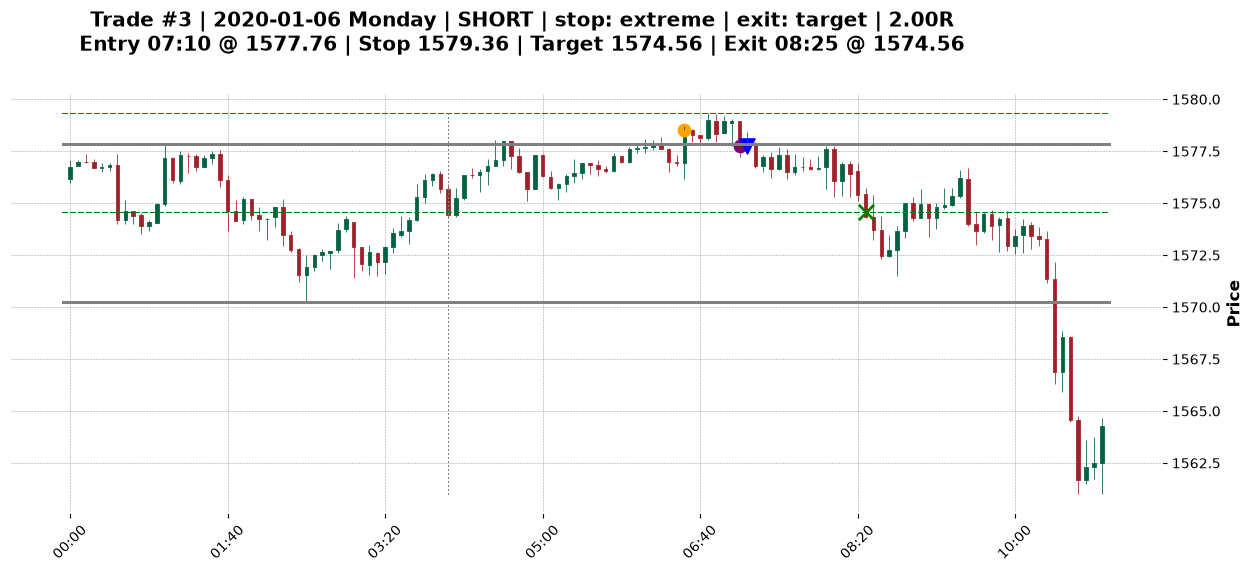

In [107]:
trade_num = 3

plot_trade_5m(trade_num)

# 4. Saving the results

We save three tables for this market and reference window, which the analysis notebook reads:

- **Daily table:** one row per day, with the reference range and the number of setups, trades and skipped setups. This includes days with no trades.
- **Trade log:** one row per trade, with every detail of the setup, entry, stop, target, exit and result.
- **Skipped log:** setups where the breakout was large and no swing point was available for the stop.

In [108]:
# label the daily table so it is self-describing like the other two
daily_out = daily.reset_index().rename(columns={"index": "ny_date"})
daily_out.insert(0, "symbol", symbol)
daily_out.insert(1, "window", window)

# save to data/cooked, named by market and reference window
daily_out.to_csv(f"../data/cooked/{symbol}_{window}_daily.csv", index=False)
trades.to_csv(f"../data/cooked/{symbol}_{window}_trades.csv", index=False)
skipped.to_csv(f"../data/cooked/{symbol}_{window}_skipped.csv", index=False)

print(f"saved {symbol} {window}: {len(daily_out)} days, {len(trades)} trades, {len(skipped)} skipped")

saved XAUUSD NY: 1557 days, 3139 trades, 44 skipped


# 5. Results

This section brings together the saved results for every market tested and reports what the historical test found. These are our findings, kept separate from the creator's presentation in the video. All results are in R, where 1R is the amount risked on a trade, and are shown before trading costs. Spread and commission would reduce them further.

Sections 2 to 4 are run once for each market. This section then reads all of the saved results together.

In [110]:
from pathlib import Path
import matplotlib.pyplot as plt


In [111]:
# config
cooked_dir = Path("../data/cooked")

trade_time_cols = ["breakout_time", "reentry_time", "entry_time", "exit_time"]


def load_all(kind, date_cols):
    """Stack every saved file of one kind (daily, trades or skipped) into a single table."""
    tables = []

    for path in sorted(cooked_dir.glob(f"*_{kind}.csv")):
        # a market with no skipped setups saves an empty file, so skip it
        try:
            tables.append(pd.read_csv(path, parse_dates=date_cols))
        except pd.errors.EmptyDataError:
            continue

    return pd.concat(tables, ignore_index=True)


all_trades = load_all("trades", trade_time_cols + ["ny_date"])
all_daily = load_all("daily", ["ny_date"])
all_skipped = load_all("skipped", ["breakout_time", "reentry_time", "ny_date"])

# one label per market and reference window
all_trades["run"] = all_trades["symbol"] + " " + all_trades["window"]

# what was loaded
pd.DataFrame({
    "trades": all_trades.groupby(["symbol", "window"]).size(),
    "days": all_daily.groupby(["symbol", "window"]).size(),
    "valid days": all_daily.groupby(["symbol", "window"])["valid_range"].sum(),
    "skipped": all_skipped.groupby(["symbol", "window"]).size()
}).fillna(0).astype(int)

,,trades,days,valid days,skipped
symbol,window,,,,
BTCUSD,NY,3148,1564,1559,62
EURUSD,NY,3109,1564,1553,28
XAUUSD,NY,3139,1557,1543,44


### Headline results

The main numbers for each market: how often the strategy trades, how often trades win, what they return in total, and how deep the drawdowns go.

In [112]:
def summarise(r):
    """Headline statistics for trade results in R, in time order."""
    # running total of R, and how far it falls below its previous peak
    equity = r.cumsum()
    drawdown = equity.cummax().clip(lower=0) - equity

    # longest run of consecutive losing trades
    losing = (r < 0).astype(int)
    longest_losing_streak = losing.groupby((losing == 0).cumsum()).sum().max()

    return {
        "Win rate": f"{(r > 0).mean():.1%}",
        "Average R per trade": round(r.mean(), 3),
        "Total R": round(r.sum(), 1),
        "Profit factor": round(r[r > 0].sum() / -r[r < 0].sum(), 2),
        "Max drawdown (R)": round(drawdown.max(), 1),
        "Longest losing streak": int(longest_losing_streak)
    }


headline = {}

for (symbol, window), group in all_trades.groupby(["symbol", "window"]):
    group = group.sort_values("entry_time")
    days = all_daily[(all_daily["symbol"] == symbol) & (all_daily["window"] == window) & all_daily["valid_range"]]

    row = {
        "Trades": len(group),
        "Trades per valid day": round(len(group) / len(days), 2),
        "Days with no setup": f"{(days['setups'] == 0).mean():.1%}"
    }

    for name, value in summarise(group["result_r"]).items():
        row[name] = value

    headline[f"{symbol} {window}"] = row

pd.DataFrame(headline)

,BTCUSD NY,EURUSD NY,XAUUSD NY
Trades,3148,3109,3139
Trades per valid day,2.02,2.0,2.03
Days with no setup,10.6%,10.7%,10.1%
Win rate,37.8%,36.8%,37.7%
Average R per trade,0.008,-0.025,0.01
Total R,24.4,-79.0,32.3
Profit factor,1.01,0.96,1.02
Max drawdown (R),86.2,118.2,80.7
Longest losing streak,19,14,19


### Equity curve

The running total of R, trade by trade, for each market over the full test period. A strategy with an edge rises steadily over time. One without an edge wanders around zero.

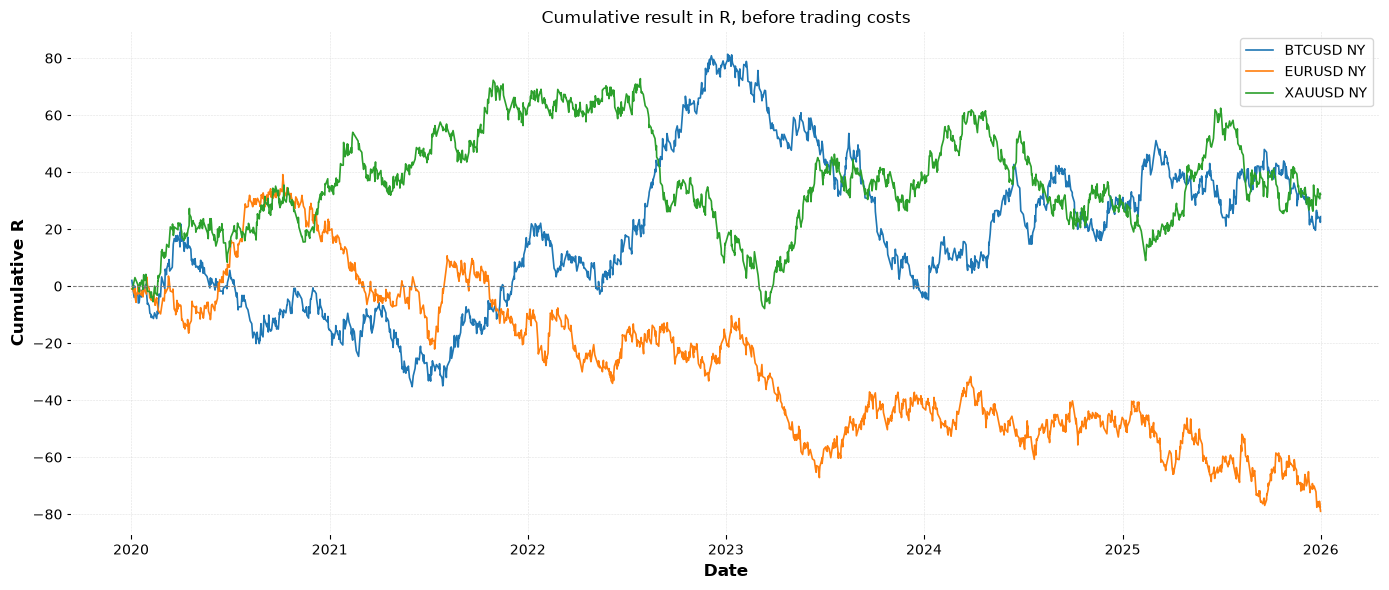

In [113]:
fig, ax = plt.subplots(figsize=(14, 6))

for run, group in all_trades.groupby("run"):
    group = group.sort_values("exit_time")

    # running total of R at the time each trade closed
    ax.plot(group["exit_time"], group["result_r"].cumsum(), label=run, linewidth=1.2)

# breakeven line
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")

ax.set_title("Cumulative result in R, before trading costs")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative R")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### How trades end

How each market's trades finished (target, stop, end of day or Friday close) and what each type of exit returned on average. We also look at how often a losing trade was in profit before it was stopped out.

In [114]:
# share of trades by exit reason, per market
exit_mix = pd.crosstab(all_trades["exit_reason"], all_trades["run"], normalize="columns").mul(100).round(1)

# average result in R for each exit reason, per market
exit_r = all_trades.pivot_table(index="exit_reason", columns="run", values="result_r", aggfunc="mean").round(2)

print("share of trades by exit (%)")
display(exit_mix)

print("average result by exit (R)")
display(exit_r)

# stopped-out trades that were at least 1R in profit before the stop was hit
stops = all_trades[all_trades["exit_reason"] == "stop"]
was_in_profit = (stops["mfe_r"] >= 1).groupby(stops["run"]).mean().mul(100).round(1)

print("stopped-out trades that first reached +1R (%)")
was_in_profit

share of trades by exit (%)


run,BTCUSD NY,EURUSD NY,XAUUSD NY
exit_reason,,,
both_touched,0.2,0.4,0.6
end_of_day,14.2,15.7,15.6
friday_close,4.1,4.1,3.6
stop,55.2,55.5,54.3
stop_gap,0.1,0.0,0.2
target,26.2,24.3,25.6
target_gap,0.0,0.0,0.1


average result by exit (R)


run,BTCUSD NY,EURUSD NY,XAUUSD NY
exit_reason,,,
both_touched,-1.00,-1.00,-1.00
end_of_day,0.20,0.25,0.26
friday_close,0.24,0.20,0.21
stop,-1.00,-1.00,-1.00
stop_gap,-1.23,-1.02,-1.22
target,2.00,2.00,2.00
target_gap,2.35,2.13,2.06


stopped-out trades that first reached +1R (%)


run
BTCUSD NY    22.2
EURUSD NY    22.4
XAUUSD NY    19.8
Name: mfe_r, dtype: float64

### Results by year

Total R for each market in each calendar year, with the number of trades. This shows whether results were steady or concentrated in particular years.

In [115]:
# year of each trade, from its New York date
all_trades["year"] = all_trades["ny_date"].dt.year

# total R per year, per market
yearly_r = all_trades.pivot_table(index="year", columns="run", values="result_r", aggfunc="sum").round(1)

# number of trades per year, per market
yearly_trades = all_trades.pivot_table(index="year", columns="run", values="result_r", aggfunc="size")

print("total R by year")
display(yearly_r)

print("trades by year")
yearly_trades

total R by year


run,BTCUSD NY,EURUSD NY,XAUUSD NY
year,,,
2020,-15.2,19.5,33.3
2021,28.9,-30.2,29.0
2022,63.7,-7.5,-47.7
2023,-79.4,-24.4,22.5
2024,31.2,-3.6,-8.8
2025,-4.8,-33.0,4.1


trades by year


run,BTCUSD NY,EURUSD NY,XAUUSD NY
year,,,
2020,465,474,467
2021,524,510,522
2022,505,524,523
2023,529,522,539
2024,552,522,536
2025,573,557,552


### Profit and loss in dollars

To show results in dollars, every trade is opened with the same position size on each market: 100,000 euros on EURUSD, 100 ounces on gold, and 1 Bitcoin on Bitcoin.

Because the position size stays the same, the amount at risk changes from trade to trade. A trade with a wide stop risks more money than one with a tight stop.

All three markets are priced in US dollars, so the profit or loss on a trade is simply the price move multiplied by the position size. Results are before trading costs.

In [121]:
# config
# lot size used for every trade, per market
lot_size = {
    "EURUSD": 1.0,
    "XAUUSD": 1.0,
    "BTCUSD": 1.0
}

# units per lot on this broker
contract_size = {
    "EURUSD": 100000,
    "XAUUSD": 100,
    "BTCUSD": 1
}

# +1 for longs, -1 for shorts, so a favourable move is always positive
direction_sign = np.where(all_trades["direction"] == "long", 1, -1)

# price move in the trade's favour, times units traded
price_move = (all_trades["exit_price"] - all_trades["entry_price"]) * direction_sign
units = all_trades["symbol"].map(lot_size) * all_trades["symbol"].map(contract_size)

all_trades["pnl_usd"] = price_move * units

# total dollars alongside total R, to compare the two views
pd.DataFrame({
    "Total R": all_trades.groupby("run")["result_r"].sum().round(1),
    "Total P&L ($)": all_trades.groupby("run")["pnl_usd"].sum().round(0),
    "Average trade ($)": all_trades.groupby("run")["pnl_usd"].mean().round(0),
    "Largest loss ($)": all_trades.groupby("run")["pnl_usd"].min().round(0)
})

,Total R,Total P&L ($),Average trade ($),Largest loss ($)
run,,,,
BTCUSD NY,24.4,2661.0,1.0,-2786.0
EURUSD NY,-79.0,-4171.0,-1.0,-809.0
XAUUSD NY,32.3,23963.0,8.0,-4680.0


In [122]:
# gold by year: R, dollars, and the typical stop width that links them
gold = all_trades[all_trades["symbol"] == "XAUUSD"]

gold.groupby("year").agg(
    total_r=("result_r", "sum"),
    total_usd=("pnl_usd", "sum"),
    median_risk=("risk", "median")
).round(2)

,total_r,total_usd,median_risk
year,,,
2020,33.27,24728.0,4.19
2021,28.98,12917.0,3.09
2022,-47.71,-23619.0,3.58
2023,22.48,22293.0,2.92
2024,-8.80,-10227.0,3.93
2025,4.07,-2129.0,7.10


In [123]:
# gold trades split into four equal groups by stop width
gold = all_trades[all_trades["symbol"] == "XAUUSD"].copy()
gold["risk_group"] = pd.qcut(gold["risk"], 4, labels=["narrowest", "narrow", "wide", "widest"])

gold.groupby("risk_group", observed=True).agg(
    trades=("result_r", "size"),
    total_r=("result_r", "sum"),
    total_usd=("pnl_usd", "sum"),
    median_risk=("risk", "median")
).round(2)

,trades,total_r,total_usd,median_risk
risk_group,,,,
narrowest,786,-2.04,389.0,1.38
narrow,787,-3.08,946.0,2.95
wide,781,-5.83,-2539.0,5.24
widest,785,43.23,25167.0,10.56


### Equity curve in dollars

The running total of profit and loss in dollars for each market, using the fixed position sizes above and before trading costs. Each market has its own panel because their dollar scales are very different.

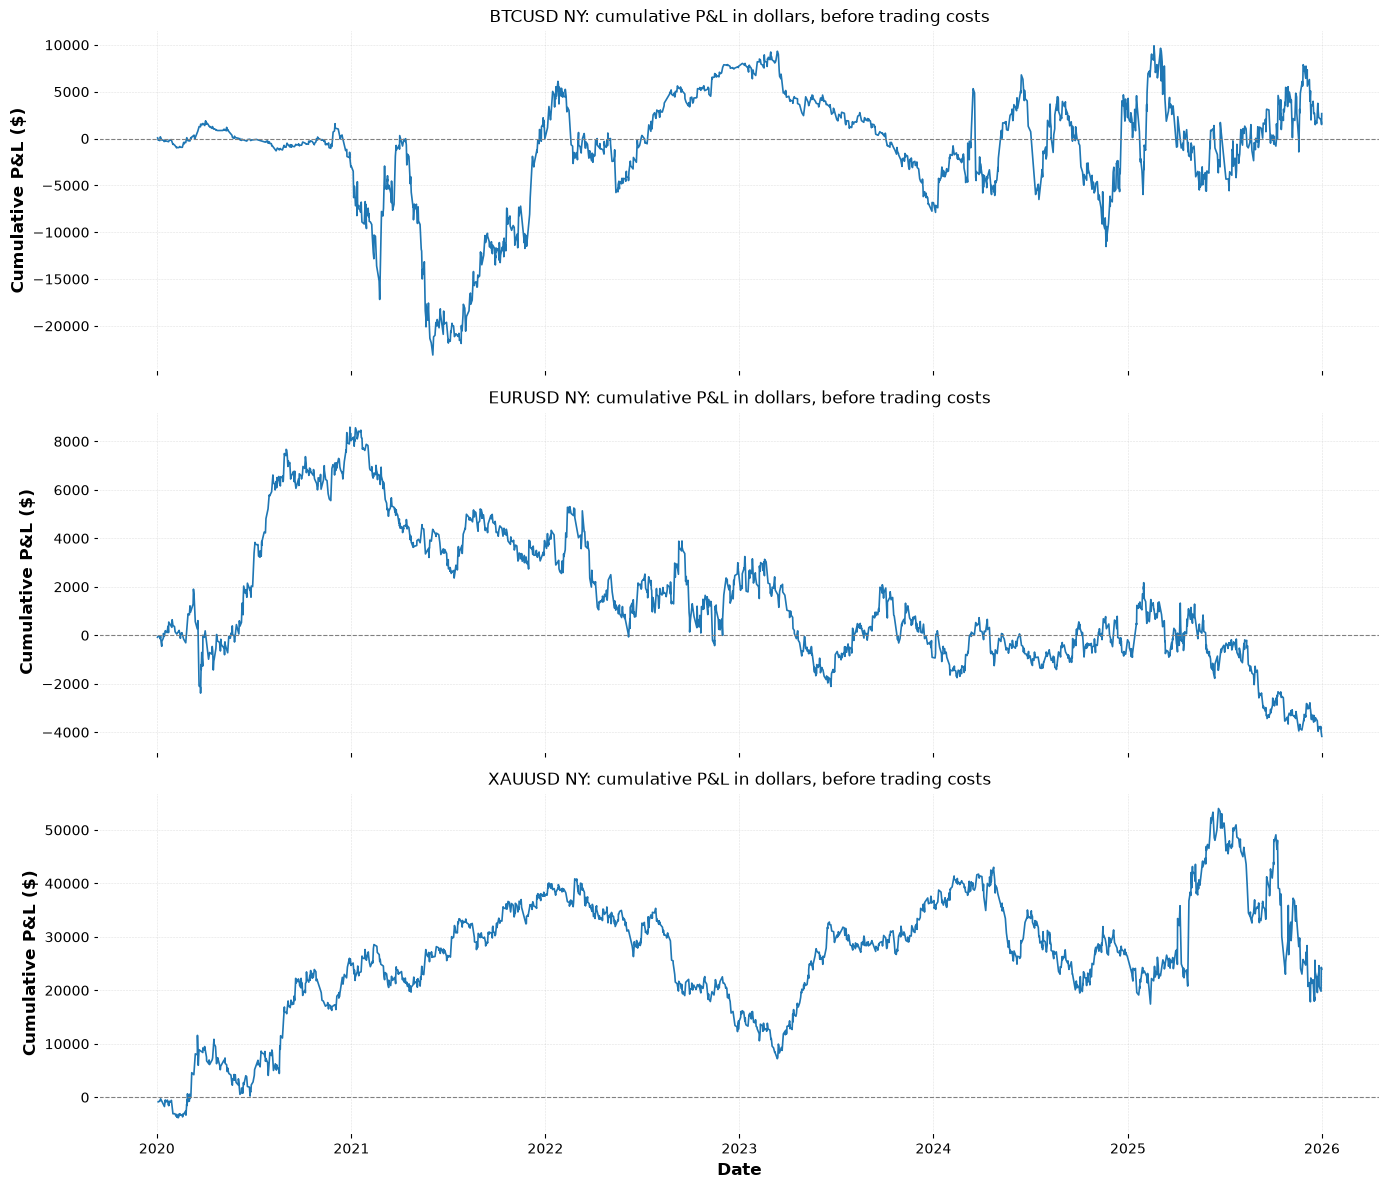

In [124]:
runs = sorted(all_trades["run"].unique())

fig, axes = plt.subplots(len(runs), 1, figsize=(14, 4 * len(runs)), sharex=True)

for ax, run in zip(axes, runs):
    group = all_trades[all_trades["run"] == run].sort_values("exit_time")

    # running total of dollars at the time each trade closed
    ax.plot(group["exit_time"], group["pnl_usd"].cumsum(), linewidth=1.2)

    # breakeven line
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")

    ax.set_title(f"{run}: cumulative P&L in dollars, before trading costs")
    ax.set_ylabel("Cumulative P&L ($)")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [127]:
# config
report_dir = Path("../report")
report_dir.mkdir(exist_ok=True)
report_path = report_dir / "first-4h-candle-reentry_results.xlsx"

# summary: headline numbers per market, plus dollar totals
summary = pd.DataFrame(headline).T
summary["Total P&L ($)"] = all_trades.groupby("run")["pnl_usd"].sum().round(0)

# by year: R, dollars and trades side by side
by_year = all_trades.pivot_table(
    index="year",
    columns="run",
    values=["result_r", "pnl_usd"],
    aggfunc="sum"
).round(1)
by_year = by_year.rename(columns={"result_r": "Total R", "pnl_usd": "P&L ($)"})

# by month: each calendar month in sequence
all_trades["month"] = all_trades["ny_date"].dt.to_period("M").astype(str)
by_month = all_trades.pivot_table(
    index="month",
    columns="run",
    values=["result_r", "pnl_usd"],
    aggfunc="sum"
).round(1)
by_month = by_month.rename(columns={"result_r": "Total R", "pnl_usd": "P&L ($)"})

# trade log without the helper columns and the unused cost columns
trade_log = all_trades.drop(
    columns=["run", "year", "month", "spread_points", "spread_cost_r", "result_r_net"],
    errors="ignore"
)

# the rules as tested, one per row
rules = pd.DataFrame({
    "Rule": [
        "Reference candle",
        "Setup window",
        "Breakout",
        "Re-entry",
        "Direction",
        "Entry",
        "Stop (normal)",
        "Stop (large breakout)",
        "Target",
        "Same-candle hit",
        "End of day",
        "Trades at a time"
    ],
    "As tested": [
        "00:00 to 04:00 New York time; its high and low form the range",
        "04:00 until midnight New York time; Fridays end at 17:00",
        "A 5-minute candle closes beyond the range; wicks do not count",
        "After a breakout, a 5-minute candle closes back inside the range",
        "Break above then re-entry is a short; break below then re-entry is a long",
        "Open of the candle after the re-entry",
        "Highest high (short) or lowest low (long) of the breakout move",
        "If the stop distance exceeds 2x the range height: nearest swing point confirmed before entry; no swing means no trade",
        "2 times the risk",
        "Counted as a loss",
        "Open trades close at the last candle before the cutoff",
        "One"
    ]
})

# assumptions behind the numbers
assumptions = pd.DataFrame({
    "Item": [
        "Source",
        "Markets",
        "Period",
        "Data",
        "Weekends",
        "Position size",
        "Trading costs"
    ],
    "Detail": [
        "YouTube: https://www.youtube.com/watch?v=O5eC5lY7ZXY",
        "EURUSD, XAUUSD (gold), BTCUSD (Bitcoin)",
        "1 January 2020 to 31 December 2025",
        "5-minute candles from MetaTrader 5, converted to New York time",
        "Excluded for all markets",
        "100,000 euros on EURUSD, 100 ounces on gold, 1 Bitcoin on Bitcoin, on every trade",
        "Not included; spread and commission would reduce results further"
    ]
})

with pd.ExcelWriter(report_path) as writer:
    summary.to_excel(writer, sheet_name="Summary")
    by_year.to_excel(writer, sheet_name="By year")
    by_month.to_excel(writer, sheet_name="By month")
    exit_mix.to_excel(writer, sheet_name="Exits", startrow=1)
    exit_r.to_excel(writer, sheet_name="Exits", startrow=len(exit_mix) + 5)
    trade_log.to_excel(writer, sheet_name="Trades", index=False)
    rules.to_excel(writer, sheet_name="Rules", index=False)
    assumptions.to_excel(writer, sheet_name="Assumptions", index=False)

print(f"saved {report_path}")

saved ..\report\first-4h-candle-reentry_results.xlsx


# 6. Conclusion

We tested the first 4H candle breakout and re-entry strategy as closely as possible to how it is presented in the video, on EURUSD, gold and Bitcoin, using 5-minute data from 2020 to 2025. That gave around 3,100 trades per market.

## What we found

- **The strategy trades often.** It takes about 2 trades per day, and roughly 9 days in 10 produce at least one setup.
- **Before trading costs, the results are close to breakeven on all three markets.** The average result per trade ranges from −0.025R to +0.010R, and profit factors sit between 0.96 and 1.02. Over six years, the total was +24.4R on Bitcoin, −79.0R on EURUSD and +32.3R on gold.
- **The results swing a lot.** Drawdowns reached 80 to 118R, and single years ranged from +63.7R to −79.4R. A test over a few days, weeks or even a full year can make the strategy look very good or very bad, depending on when it is run.
- **The three markets behave almost identically.** About 55% of trades hit the stop, 25% reach the target, and 20% are closed at the end of the day or on Friday, whichever market is traded.
- **In dollars, with the same position size on every trade, the totals before costs were +$2,661 on Bitcoin, −$4,171 on EURUSD and +$23,963 on gold.** These figures depend heavily on a small number of trades with very wide stops, and on how far prices moved over the period, so they should not be read as an edge.
- **Trading costs are not included, and they would outweigh these results.** At a typical retail gold spread of $0.20 to $0.30 per ounce, the spread alone on 3,139 trades of 100 ounces would come to roughly $60,000 to $95,000. On EURUSD, a 1-pip spread on 3,109 trades of 100,000 euros would cost about $31,000.

## Limitations

- The data comes from one broker through MetaTrader 5. Other data feeds may differ slightly.
- Weekends are excluded for all markets, including Bitcoin.
- The creator handles very large breakouts with discretion. We turned this into a fixed rule: a breakout is large when the stop distance is more than 2 times the range height, and the stop then moves to the nearest confirmed swing point.
- When a single candle touches both the stop and the target, the trade is counted as a loss, since the order of events cannot be known from 5-minute data.
- The cost figures above use typical retail spreads, not the spreads of any particular broker.

## What comes next

Traded exactly as presented, the strategy does not show an edge. The trade data still has more to tell us, though, and it deserves a closer look. We will be digging into it further.

## Decision log

Every choice made where the video was unclear or a rule had to be made precise, with the reason behind it.

### Data

| Decision | Why |
|---|---|
| Use only 5-minute data, and build the 4-hour range from it | The broker's own 4-hour candles start at different times from the New York day, so they cannot give the candle the video describes |
| Convert broker time to New York time by subtracting 7 hours | The broker's clock runs 7 hours ahead of New York all year. We confirmed this from the data: the weekly open lands at the same New York time in every month, through daylight saving changes |
| Exclude weekends for all markets | The broker did not provide weekend Bitcoin data for part of the period. Excluding weekends everywhere keeps every year and market comparable |
| Never fill missing candles, and skip days without a complete range | Filling gaps would mean inventing prices. A range built from incomplete data is not the range a trader would have seen |

### The trading day

| Decision | Why |
|---|---|
| Reference candle is 00:00 to 04:00 New York time | The video says to use New York time and take the first 4-hour candle of the day |
| Setups run from 04:00 until midnight, and open trades close at midnight | The video says trades happen within the same day as the range, but does not say what happens to a trade still open at the end of the day |
| Every market stops at 17:00 on Friday | Forex and gold close then, and the early Bitcoin data also ends there. One rule keeps the markets comparable |

### Setups and entry

| Decision | Why |
|---|---|
| A breakout needs a close strictly beyond the range; a close exactly on the line counts as inside | The video says wicks do not count, only closes |
| A close straight through to the other side of the range starts a new breakout | It is not a re-entry, because price never closed inside |
| Entry is at the open of the candle after the re-entry | It is the first price a trader could actually get once the re-entry candle has closed |
| One trade at a time. If price is still outside the range when a trade closes, that move counts as the next breakout, measured from where it first closed outside | The creator takes exactly these trades in the video, after being stopped out |

### Stops

| Decision | Why |
|---|---|
| The stop goes at the highest high (short) or lowest low (long) from the breakout candle to the re-entry candle | The video places the stop at the extreme of the breakout move |
| A breakout is large when the stop distance is more than 2 times the range height. The stop then moves to the nearest swing point, confirmed before entry. With no swing point, the setup is skipped | The creator moves the stop on very large breakouts but gives no rule for it. We fixed one before seeing any results, so it could be tested consistently |
| A swing point is a high or low with 2 candles on each side, and must be confirmed by the time the re-entry candle closes | It is a standard definition, and requiring confirmation stops the test from using a level the trader could not yet see |
| The stop triggers when price touches it, not on a candle close | The creator uses real stop orders in the video, which fill as soon as price reaches them |

### Exits

| Decision | Why |
|---|---|
| The target is 2 times the risk | The creator uses 2R on every example trade |
| Stop and target checks start from the entry candle itself | The trade is open for that whole candle, so ignoring it would miss real stop-outs |
| If one candle touches both the stop and the target, the trade is a loss | 5-minute data cannot show which came first, so we take the cautious result |
| If a candle opens beyond the stop or target, the trade exits at that open | That is the price a real order would get |

### Results

| Decision | Why |
|---|---|
| Results are measured in R | It puts every trade and every market on the same scale, whatever the price level |
| Dollar results use the same position size on every trade: 100,000 euros, 100 ounces of gold, 1 Bitcoin | It reflects how many retail traders trade, and it is described in units so it means the same thing at any broker |
| Trading costs are left out of the results | The spread recorded in this data comes from a raw-spread account and is mostly zero, so it does not reflect what a typical retail trader pays. Typical costs are discussed in the conclusion instead |
| The rules were built on six months of data, then run on the full period without changes | The six months were only used to fix places where the code did not match the rules, never to improve results |